In [3]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
from shapely.geometry import Point
import matplotlib as mpl
from matplotlib.patches import Rectangle
import numpy as np
import matplotlib.patches as Patches

In [4]:
v6cell = '/Users/griffinberonio/Documents/Holloway_Group/Data/monitor_data/V6NA01.counties_under_50_2021-2023_grid_cells.gpkg'
county_shapefile = gpd.read_file('/Users/griffinberonio/Documents/Holloway_Group/Data/map_shapefiles/tl_2023_us_county/tl_2023_us_county.shp')

v6cells = gpd.read_file(v6cell)

In [5]:
conus = ['01', '04', '05', '06', '08', '09', '10', '11', '12', '13', '16', '17', '18', '19', '20', '21', '22', '23', '24', '25', '26', '27', '28', '29', '30', '31', '32', '33', '34', '35', '36', '37', '38', '39', '40', '41', '42', '44', '45', '46', '47', '48', '49', '50', '51', '53', '54', '55', '56']
county_conus = county_shapefile[county_shapefile['STATEFP'].isin(conus)]

In [6]:
v6cellstrans = v6cells.to_crs(epsg=4326)
county_conus = county_conus.to_crs(epsg=4326)

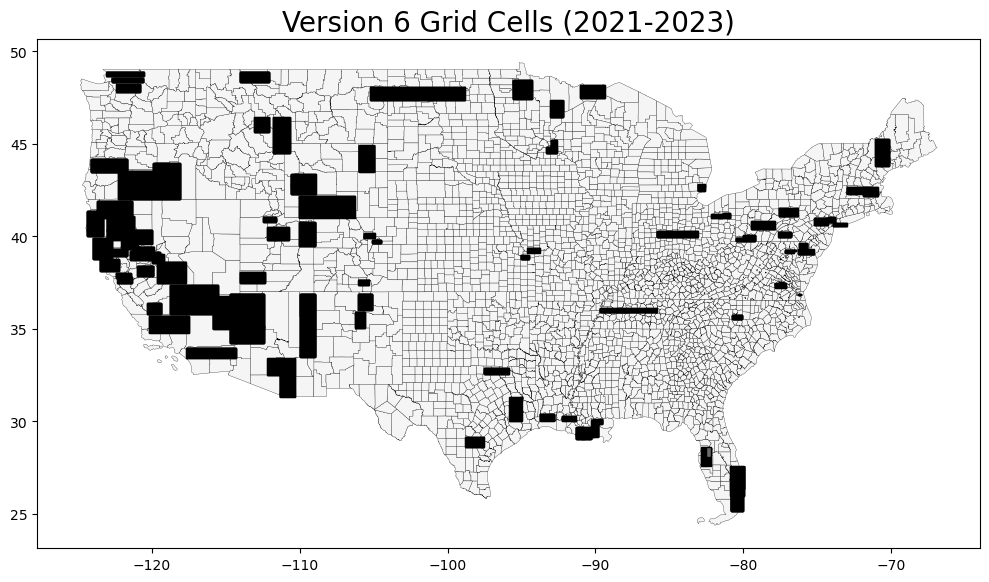

In [18]:
fig, ax = plt.subplots(figsize=(10, 12))

county_conus.plot(ax=ax, facecolor='#f5f5f5', edgecolor='black', linewidth=0.2, zorder=1)
v6cellstrans.plot(ax=ax, facecolor='#6B6B6B', edgecolor='black',zorder=2)

plt.title('Version 6 Grid Cells (2021-2023)', fontsize = 20)
plt.tight_layout()

In [20]:
v5alignment = pd.read_csv('/Users/griffinberonio/Documents/Holloway_Group/Data/monitor_data/V5_misaligned_hotspots_0-50')

county_layer = v5alignment[['COUNTYFP','GEOID', 'NAME', 'NAMELSAD',
       'STUSPS', 'STATE_NAME', 'total_monitors', 'pct','geometry']]
county_layer['geometry'] = gpd.GeoSeries.from_wkt(county_layer.loc[:,'geometry'])

countydf = gpd.GeoDataFrame(county_layer,
                            geometry=county_layer['geometry'],
                            crs=4326)

cols_to_keep = ['COUNTYFP','GEOID','NAME','STATE_NAME','total_monitors','pct',
                'geometry']

fulldf = countydf[cols_to_keep]
fulldf.head()

/var/folders/d1/xmw0d36x7fn39t0jfvtsbzk80000gn/T/ipykernel_28003/2391735173.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  county_layer['geometry'] = gpd.GeoSeries.from_wkt(county_layer.loc[:,'geometry'])


,COUNTYFP,GEOID,NAME,STATE_NAME,total_monitors,pct,geometry
0,710,51710,Norfolk,Virginia,1.0,0.0,"POLYGON ((1723079.25831 1723223.43689, 1722984..."
1,103,12103,Pinellas,Florida,2.0,0.0,"MULTIPOLYGON (((1314191.18293 603182.51965, 13..."
2,103,12103,Pinellas,Florida,2.0,0.0,"MULTIPOLYGON (((1314191.18293 603182.51965, 13..."
3,27,24027,Howard,Maryland,1.0,0.0,"POLYGON ((1596151.12431 1971589.49678, 1596320..."
4,35,41035,Klamath,Oregon,1.0,0.0,"POLYGON ((-2131411.9529 2421846.74215, -213121..."


In [28]:
def bounding_boxes(countydf):
    rows = []
    for geoid, tempcounty in countydf.groupby('GEOID'):
        bounds = tempcounty.total_bounds  # [minx, miny, maxx, maxy] as one county
        rows.append({
            'county': tempcounty['NAME'].iloc[0],
            'GEOID': geoid,
            'minx': bounds[0],
            'miny': bounds[1],
            'maxx': bounds[2],
            'maxy': bounds[3],
            'geometry': tempcounty['geometry'].iloc[0]
        })
    return gpd.GeoDataFrame(rows, crs=countydf.crs)
        
boxesfull = bounding_boxes(fulldf)

boxesfull.shape

(96, 7)

In [29]:
import xarray as xr
import pandas as pd
import geopandas as gpd
from shapely.geometry import Point

def clip_v6(satfile, uncfile, boxdf, countydf, buffer=0, version=6, proj_crs="EPSG:5070"):
    target_counties = list(boxdf['county'].unique())
    county_bounds = None

    for county in target_counties:
        print(f'Starting Process for: {county} County...')

        tempslice = boxdf[boxdf['county'] == county]
        minx, maxx = tempslice['minx'].values[0], tempslice['maxx'].values[0]
        miny, maxy = tempslice['miny'].values[0], tempslice['maxy'].values[0]
        geoid = tempslice['GEOID'].values[0]

        # --- get the real county polygon (not the box) ---
        county_geom = countydf[countydf['GEOID'] == geoid, 'geometry'].values[0]

        with xr.open_dataset(satfile, engine='netcdf4') as ds_sat:
            lat_ascending = ds_sat['lat'].values[0] < ds_sat['lat'].values[-1]
            lat_slice = slice(miny - buffer, maxy + buffer) if lat_ascending else slice(maxy + buffer, miny - buffer)   

            lon_slice = slice(minx - buffer, maxx + buffer)
            sat_data = ds_sat.sel(lon=lon_slice, lat=lat_slice).to_dataframe()

        with xr.open_dataset(uncfile, engine='netcdf4') as ds_unc:
            unc_data = ds_unc.sel(lon=lon_slice, lat=lat_slice).to_dataframe()

        if version == 6:
            unc_data = unc_data.rename(columns={'PM25': 'GWRPM25SIGMA'})
            merged = pd.merge(sat_data, unc_data, left_index=True, right_index=True, how='inner')
            merged.reset_index(inplace=True)
            merged['percent'] = (merged['GWRPM25SIGMA'] / merged['PM25']) * 100
            to_use = merged[merged['percent'] < 90][['lat', 'lon', 'PM25']]
        elif version == 5:
            merged = pd.merge(sat_data, unc_data, left_index=True, right_index=True, how='left').reset_index()
            merged['percent'] = (merged['GWRPM25SIGMA'] / merged['GWRPM25']) * 100
            to_use = merged[merged['percent'] < 90][['lat', 'lon', 'GWRPM25']]

        if to_use.empty:
            continue

        # --- real spatial filter: keep only cells that actually fall in this county's polygon ---
        pts = gpd.GeoDataFrame(
            to_use,
            geometry=[Point(xy) for xy in zip(to_use['lon'], to_use['lat'])],
            crs="EPSG:4326"
        )
        pts_in_county = pts[pts.within(county_geom)].copy()

        pts_in_county['county'] = county
        pts_in_county['GEOID'] = geoid

        county_bounds = pts_in_county if county_bounds is None else pd.concat([county_bounds, pts_in_county], ignore_index=True)

    return county_bounds

In [30]:
v6unc2023 = '/Users/griffinberonio/Documents/Holloway_Group/Data/WashU_V6_NA/V6NA01.CNNPM25.AbsoluteUncertainty.202301-202312.nc'
v6data2023 = '/Users/griffinberonio/Documents/Holloway_Group/Data/WashU_V6_NA/V6NA01.CNNPM25.PM25.202301-202312.nc'
v6unc2022 = '/Users/griffinberonio/Documents/Holloway_Group/Data/WashU_V6_NA/V6NA01.CNNPM25.AbsoluteUncertainty.202201-202212.nc'
v6data2022 = '/Users/griffinberonio/Documents/Holloway_Group/Data/WashU_V6_NA/V6NA01.CNNPM25.PM25.202201-202212.nc'
v6unc2021 = '/Users/griffinberonio/Documents/Holloway_Group/Data/WashU_V6_NA/V6NA01.CNNPM25.AbsoluteUncertainty.202101-202112.nc'
v6data2021 = '/Users/griffinberonio/Documents/Holloway_Group/Data/WashU_V6_NA/V6NA01.CNNPM25.PM25.202101-202112.nc'

In [31]:
clipped2021 = clip_v6(v6data2021,v6unc2021,boxesfull,fulldf,0.1)
clipped2022 = clip_v6(v6data2022,v6unc2022,boxesfull,fulldf,0.1)
clipped2023 = clip_v6(v6data2023,v6unc2023,boxesfull,fulldf,0.1)

threeyears = pd.concat([clipped2021,clipped2022,clipped2023])

Starting Process for: Apache County...


InvalidIndexError: (0      False
1      False
2      False
3      False
4      False
       ...  
165    False
166    False
167    False
168    False
169    False
Name: GEOID, Length: 170, dtype: bool, 'geometry')